In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [12]:
def build_model(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [13]:
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.legend(); plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.legend(); plt.title('Accuracy')
    plt.show()

In [ ]:
def visualize_first_layer(model, x_sample, fname="first_layer_maps.png"):
    # force model to build symbolic graph
    _ = model(tf.zeros((1, 32, 32, 3)))

    # get first conv layer
    first_conv = None
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            first_conv = layer
            break
    assert first_conv is not None, "No Conv2D layer found"

    activation_model = models.Model(
        inputs=model.inputs,
        outputs=first_conv.output
    )

    activations = activation_model.predict(
        np.expand_dims(x_sample, 0),
        verbose=0
    )[0]  # H x W x C

    n_maps = activations.shape[-1]
    cols = 8
    rows = int(np.ceil(n_maps / cols))

    plt.figure(figsize=(cols * 1.5, rows * 1.5))
    for i in range(n_maps):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(activations[:, :, i], cmap="viridis")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [15]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [16]:
model = build_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Program Files\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
EPOCHS = 10
BATCH_SIZE = 64
history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.1, verbose=2)
model.save("cifar_keras.keras")

Epoch 1/10
704/704 - 12s - 17ms/step - accuracy: 0.4740 - loss: 1.4606 - val_accuracy: 0.5682 - val_loss: 1.2115
Epoch 2/10
704/704 - 9s - 13ms/step - accuracy: 0.6327 - loss: 1.0460 - val_accuracy: 0.6364 - val_loss: 1.0274
Epoch 3/10
704/704 - 11s - 16ms/step - accuracy: 0.6936 - loss: 0.8756 - val_accuracy: 0.6868 - val_loss: 0.8878
Epoch 4/10
704/704 - 11s - 16ms/step - accuracy: 0.7318 - loss: 0.7655 - val_accuracy: 0.7214 - val_loss: 0.8073
Epoch 5/10
704/704 - 10s - 15ms/step - accuracy: 0.7666 - loss: 0.6709 - val_accuracy: 0.7342 - val_loss: 0.8000
Epoch 6/10
704/704 - 11s - 15ms/step - accuracy: 0.7938 - loss: 0.5878 - val_accuracy: 0.7260 - val_loss: 0.8153
Epoch 7/10
704/704 - 12s - 17ms/step - accuracy: 0.8198 - loss: 0.5184 - val_accuracy: 0.7470 - val_loss: 0.7869
Epoch 8/10
704/704 - 10s - 14ms/step - accuracy: 0.8410 - loss: 0.4516 - val_accuracy: 0.7426 - val_loss: 0.7952
Epoch 9/10
704/704 - 19s - 27ms/step - accuracy: 0.8634 - loss: 0.3901 - val_accuracy: 0.7444 - v

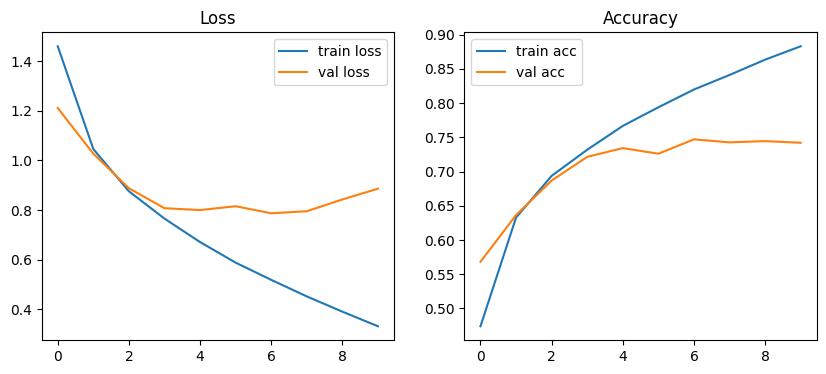

In [20]:
plot_history(history)

Saved first_layer_maps.png


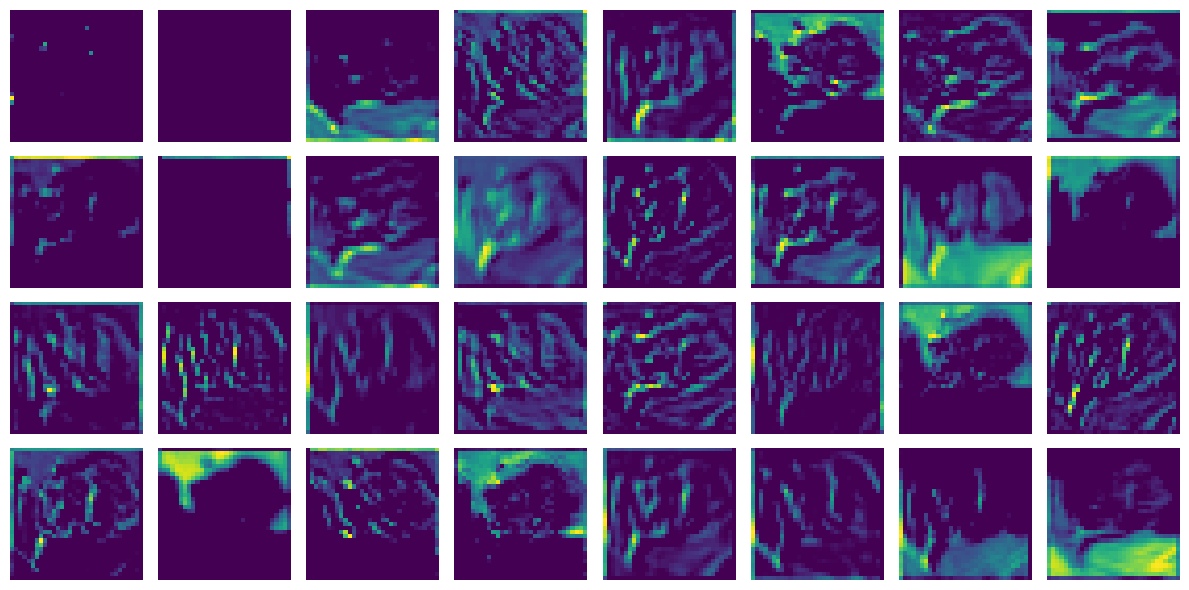

In [21]:
visualize_first_layer(model, x_test[0])